1. SETUP & IMPORT LIBRARY

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt 
import seaborn as sns
import folium
import numpy as np
from shapely.geometry import Polygon, Point

Penjelasan :
- Pandas : Membaca dan mengolah data dalam DataFrame
- Geopandas : Pandas yang menambahkan dukungan untuk data geografis pada DataFrame
- Matplotlib.pyplot : Membuat grafik dasar seperti diagram garis, batang dan lingkarang secara manual
- Seaborn : Membuat grafik statistik terlihat lebih menarik dan profesional
- Folium : Membuat peta interaktif berbasis web
- Numpy : Menghitung angka dan operasi matriks dengan cepat
- Shapely : Mengolah dan menganalisis geometri objek dua dimensi (titik, garis, poligon)

2. LOAD DATA GeoJSON

In [3]:
DF = gpd.read_file("data_point_pluvial_flood_dataset.geojson")

#Clean Data Slope
DF = DF[(DF['Slope'] >= 0) & (DF['Slope'] <= 100)]

print(DF.head(5))



          X         Y      Slope    Curvature       Aspect       TWI     FA  \
0  3.909444  7.443056  46.686142 -3.888000e+09   45.000000 -3.250368  147.0   
1  3.908611  7.442778  52.151768  1.296000e+09   60.945396 -4.313832   61.0   
2  3.908889  7.442778  66.484085  0.000000e+00   67.619865 -8.327622    1.0   
3  3.909167  7.442778  58.007183 -2.592000e+09   38.659809 -4.707937   51.0   
4  3.909444  7.442778  60.503792 -1.296000e+09  351.869904 -5.985817   15.0   

   Drainage    Rainfall     SUSCEP                 geometry  
0  228.8528  101.515616  Very_High  POINT (3.90944 7.44306)  
1  229.6781   80.409863  Very_High  POINT (3.90861 7.44278)  
2  230.5920   78.986849  Very_High  POINT (3.90889 7.44278)  
3  235.4210   81.953151  Very_High  POINT (3.90917 7.44278)  
4  234.4346   85.866027  Very_High  POINT (3.90944 7.44278)  


3. EKSPLORASI STRUKTUR DATA

In [4]:
DF.info()
DF.describe()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 144013 entries, 0 to 144400
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   X           144013 non-null  float64 
 1   Y           144013 non-null  float64 
 2   Slope       144013 non-null  float64 
 3   Curvature   144013 non-null  float64 
 4   Aspect      144013 non-null  float64 
 5   TWI         144013 non-null  float64 
 6   FA          144013 non-null  float64 
 7   Drainage    144013 non-null  float64 
 8   Rainfall    144013 non-null  float64 
 9   SUSCEP      144013 non-null  str     
 10  geometry    144013 non-null  geometry
dtypes: float64(9), geometry(1), str(1)
memory usage: 13.2 MB


,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall
count,144013.000000,144013.000000,144013.000000,1.440130e+05,144013.000000,144013.000000,144013.000000,144013.000000,144013.000000
mean,3.891544,7.374558,58.183881,-2.546770e+06,184.464709,-7.342037,1203.806434,219.714405,74.787190
std,0.027877,0.032503,15.157870,4.010003e+09,101.419126,2.084627,19834.499573,7.057898,8.891749
min,3.831111,7.311389,0.000000,-3.499200e+10,-1.000000,-10.815885,0.000000,203.729300,59.541096
25%,3.868889,7.348056,51.340191,-2.592000e+09,101.309929,-8.653046,0.000000,214.286900,68.140822
50%,3.891667,7.374167,61.980232,0.000000e+00,190.007980,-7.998810,1.000000,220.631300,73.873425
75%,3.913611,7.400556,69.167122,2.592000e+09,270.000000,-6.703169,6.000000,224.191400,81.329315
max,3.954444,7.443056,86.575409,3.888000e+10,359.144897,11.683441,457936.000000,235.421000,101.515616


4. VISUALISASI DISTRIBUSI PARAMETER 

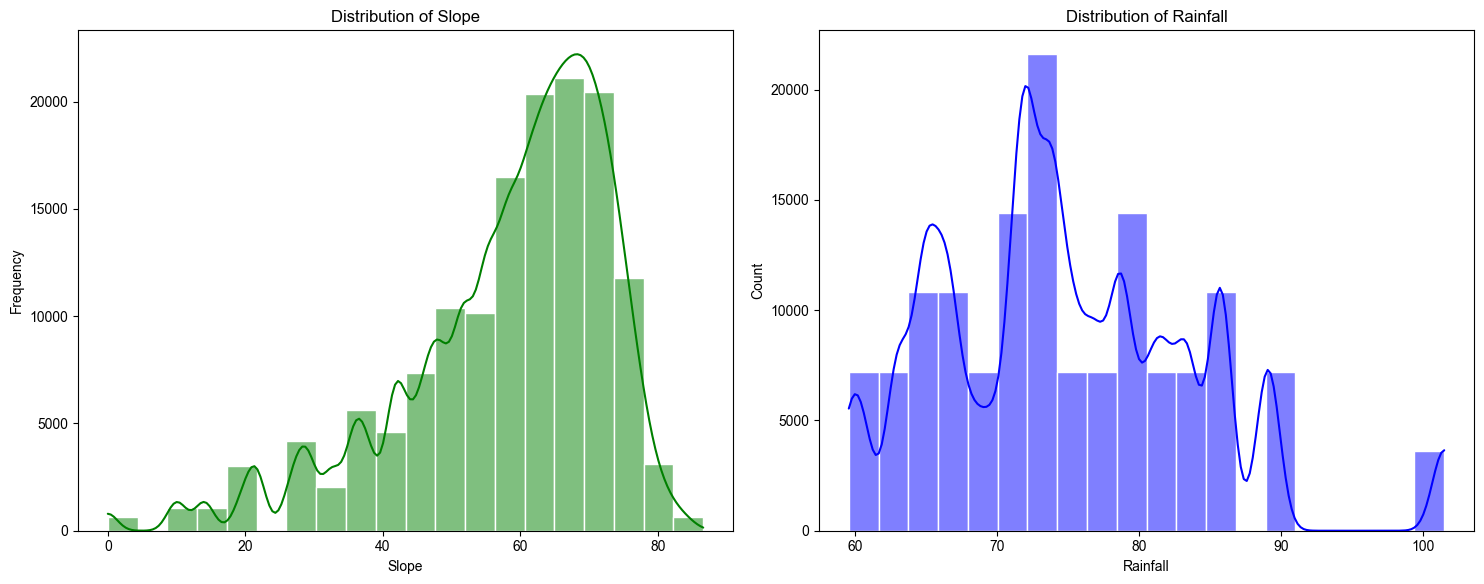

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

sns.histplot(DF["Slope"], color="green", kde=True, bins=20, ax=axes[0])
axes[0].set_title("Distribution of Slope")
axes[0].set_ylabel("Frequency")

sns.histplot(DF["Rainfall"], color="blue", kde=True, bins=20, ax=axes[1])
axes[1].set_title("Distribution of Rainfall")
axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Kesimpulan :
- Slope : Data didominasi oleh kemiringan lereng (slope) antara 60 - 75. Hal ini menunjukan sebagian besar titik banjir berada pada kemiringan lereng yang cukup curam. 
- Rainfall : Data menunjukan adanya beberapa puncak titik hujan (rainfall), puncak tertinggi yaitu pada 70-75 m. Namun curah hujan di seluruh wilayahnya relatif tinggi dan merata di angka 60 - 100 mm yang menjadi penyebab banjir pluvial (banjir karena curah hujan tinggi).

5. ANALISIS KATEGORI SUSCEPBILITY

SUSCEP
Moderate     38013
High         34359
Low          32166
Very_High    23392
No_Flood     16083
Name: count, dtype: int64


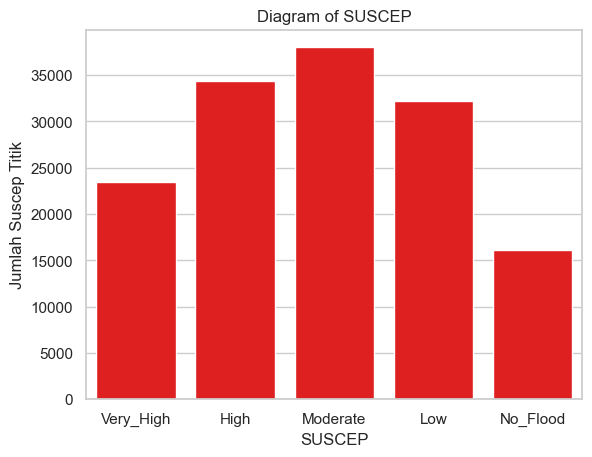

In [6]:
Jumlah_Suscep = DF['SUSCEP'].value_counts()
print(Jumlah_Suscep)

sns.countplot(data=DF, x='SUSCEP', color="red")
plt.title("Diagram of SUSCEP")
plt.ylabel("Jumlah Suscep Titik") 
plt.show()

Analisis : Wilayah ini terbagi menjadi 5 kategori kerentanan dengan jumlah titik paling banyak yaitu Moderate sebanyak 38.013 titik diikuti dengan High dan Low. Meskipun kategori Very High bukan yang terbanyak tetapi angkanya tetap tinggi 23.392 titik. Sementara No Flood merupakan yang paling sedikit. Kesimpulannya kerentanan banjir di wilayah ini cukup merata dari menengah hingga tinggi.

6. SCATTER PLOT HUBUNGAN PARAMETER

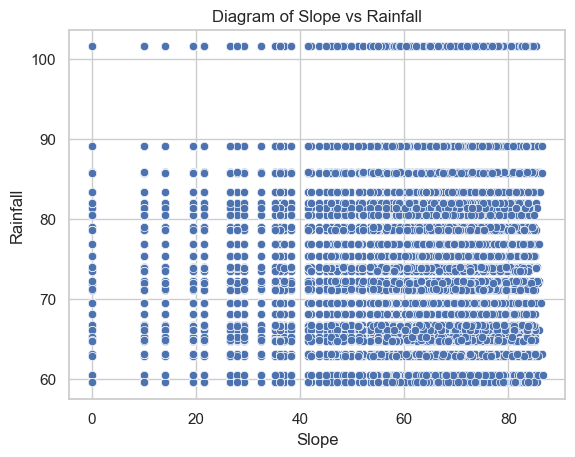

In [7]:
sns.scatterplot(data=DF, x="Slope", y="Rainfall")
plt.title("Diagram of Slope vs Rainfall")
plt.show()

Kesimpulan : Ada pola linear yang jelas. Hal tersebut menunjukan banjir bisa terjadi dimanapun baik di wilayah dengan kemiringan lereng (slope) 0 derajat sampai 80 derajat. Begitu juga pada curah hujan, banjir akan tetap terjadi ketika curah hujan berada pada 60 - 100 mm. Semua faktor dapat menjadi penyebab banjir.  

7. HEATMAP KORELASI PARAMETER

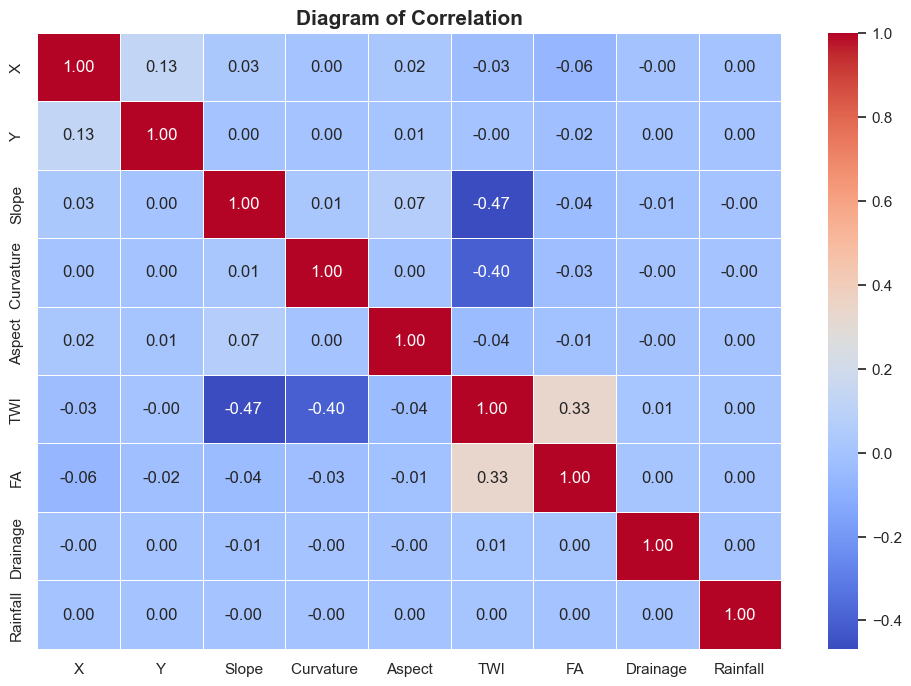

In [8]:
plt.figure(figsize=(12, 8))
cor = DF.corr(numeric_only=True)
sns.heatmap(cor, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Diagram of Correlation", fontsize=15, fontweight='bold') 
plt.show() 

8. PETA INTERAKTIF TITIK FLOOD

In [30]:
DF_sample = DF.sample(n=15, random_state=1)

m = folium.Map(location=[DF_sample['Y'].mean(), DF_sample['X'].mean()], zoom_start=12)

for index, row in DF_sample.iterrows():
    isi_info = f"""
    <b>Susceptibility:</b> {row['SUSCEP']}<br>
    <b>Slope:</b> {row['Slope']:.2f}<br>
    <b>Rainfall:</b> {row['Rainfall']:.2f}<br>
    <b>TWI:</b> {row['TWI']:.2f}
    """
    
    folium.Marker(
        location=[row['Y'], row['X']],
        popup=folium.Popup(isi_info, max_width=300),
        tooltip="Klik untuk info detail"
    ).add_to(m)

m.save("Finish_Data_Point_Sample_Flood.html")

m
    